# Laboratório 1 — Tokenizadores e embeddings

**Grandes Modelos de Linguagem: do Transformer aos Agentes de IA** · Aula 4 de 30 · CESAR

---

Nas Aulas 2 e 3 vimos que texto vira token e token vira vetor. Hoje vocês medem as duas coisas com as próprias mãos, em português.

**Este lab é de CPU.** Não selecione acelerador — o primeiro lab que pede GPU é o Lab 2, na Aula 9.

**Este notebook é autocontido.** Antes de cada checkpoint há uma seção **Conceitos** com tudo o que você precisa para executar e interpretar aquele bloco: por que subword, BPE × WordPiece × Unigram, byte-level, fertilidade, custo O(n²), one-hot e ortogonalidade, hipótese distribucional, cosseno, tarefa-proxy, amostragem negativa, PPMI/SVD, PCA × t-SNE. E cada célula de código vem precedida de **o que ela faz** e **como ler a saída dela**.

Você não precisa dos slides das Aulas 2 e 3 abertos ao lado.

As **medições** da demo da Aula 3 (`demo-embeddings`) estão incorporadas aqui, agora rodando sobre o corpus em português que **você** treinou: o zero do one-hot, a palavra ambígua, o protocolo de exclusão da analogia e a armadilha dos antônimos.

## Os quatro checkpoints

| # | O que você faz | Critério de conclusão |
|---|---|---|
| 1 | Quatro tokenizadores sobre três textos | Tabela de tokens e fertilidade + decomposição de uma palavra longa em PT |
| 2 | Razão PT/EN e a conta do custo | Razão média impressa + tabela de projeção + 3 linhas de interpretação |
| 3 | Vetores de palavra em português (skip-gram, ou contagem+SVD sem `gensim`) | Modelo treinado + método usado + vocabulário + tempo + `most_similar` de 3 palavras |
| 4 | PCA, t-SNE, vizinhos e analogias | Dois gráficos rotulados + tabela de 4–6 analogias com o resultado real |

## O que entregar (prazo: 1 semana)

1. Este notebook **executado**, com as saídas visíveis nos quatro checkpoints.
2. Respostas às **seis questões-guia** (célula markdown no fim).
3. Declaração de uso de IA — quais ferramentas, para quê, em duas linhas.

Notebook sem saídas não é avaliável.

> **O que é avaliado são os quatro checkpoints e as seis questões-guia.** As células marcadas como **Medição**, **Apêndice** ou **Conceitos** existem para você entender e argumentar — não entram na rubrica, e nenhuma delas é obrigatória para fechar um checkpoint.

## Setup

> **Sobre a instalação — leia antes de rodar.** Este lab **não fixa versão** de `gensim` nem de `scipy`. Fixar versão antiga é justamente o que travava esta célula: quando não existe *wheel* pronta para a versão de Python do ambiente, o `pip` passa a **compilar** `gensim` e `scipy` a partir do código-fonte, e a célula fica parada em `Preparing metadata (pyproject.toml)` por dezenas de minutos.
>
> A célula abaixo instala **só o que falta**, sempre com `--only-binary=:all:` — que faz o `pip` desistir em segundos se não houver wheel, em vez de compilar — e com tempo-limite.
>
> O `gensim` é **opcional**. Se ele não entrar, o Checkpoint 3 treina os vetores por **contagem + SVD**, usando só `numpy` e `scikit-learn`, e o resto do lab roda igual. A célula imprime qual caminho você pegou.
>
> **Não é preciso reiniciar o runtime.**

Rode esta célula **nos dois primeiros minutos da aula**: o download dos quatro tokenizadores acontece enquanto o instrutor explica o entregável.


#### A célula abaixo — instalar o que falta

Verifica quais bibliotecas já existem no ambiente e instala **somente as ausentes**, sempre exigindo *wheel* pronta (`--only-binary=:all:`) e com tempo-limite. Em seguida tenta o `gensim`, que é opcional, e define a variável `GENSIM_OK`.

**Como ler a saída:** a última linha diz qual caminho o Checkpoint 3 vai seguir — `Word2Vec skip-gram (gensim)` ou `contagem + PPMI + SVD`. Anote: isso entra na questão-guia 3.

**Se demorar:** não deve demorar. Se o `pip` ficar minutos parado em `Preparing metadata (pyproject.toml)`, algum pin de versão voltou para a célula e ele está compilando do código-fonte — interrompa e confira.


In [1]:
# Setup de dependências — sem pin de versão e sem compilar nada.
#
# --only-binary=:all: obriga o pip a usar wheel pronta; se não houver, ele
# falha em segundos em vez de compilar por 20+ minutos.
import importlib
import importlib.util
import subprocess
import sys

USAR_GENSIM = True    # deixe False para ir direto ao caminho contagem + SVD


def _tem(modulo):
    return importlib.util.find_spec(modulo) is not None


def _instala(*pacotes, tempo_limite=240):
    cmd = [sys.executable, "-m", "pip", "install", "-q",
           "--only-binary=:all:", *pacotes]
    try:
        return subprocess.run(cmd, capture_output=True, text=True,
                              timeout=tempo_limite).returncode == 0
    except subprocess.TimeoutExpired:
        return False


faltando = [pacote for modulo, pacote in (("transformers", "transformers"),
                                          ("sklearn", "scikit-learn"),
                                          ("matplotlib", "matplotlib"))
            if not _tem(modulo)]
if faltando:
    print("Instalando o que falta:", ", ".join(faltando))
    _instala(*faltando)
else:
    print("transformers, scikit-learn e matplotlib: já presentes.")

GENSIM_OK = False
if USAR_GENSIM:
    if not _tem("gensim"):
        print("Tentando gensim (só wheel, sem compilar)...")
        _instala("gensim")
        importlib.invalidate_caches()
    try:
        import gensim
        GENSIM_OK = True
        print(f"gensim {gensim.__version__}: disponível.")
    except Exception as e:
        print(f"gensim indisponível ({type(e).__name__}) — e está tudo bem.")

print()
print("Checkpoint 3 vai usar:",
      "Word2Vec skip-gram (gensim)" if GENSIM_OK
      else "contagem + PPMI + SVD (numpy/scikit-learn)")
print("Setup concluído. NÃO reinicie o runtime — siga para a próxima célula.")


transformers, scikit-learn e matplotlib: já presentes.
Tentando gensim (só wheel, sem compilar)...
gensim 4.4.0: disponível.

Checkpoint 3 vai usar: Word2Vec skip-gram (gensim)
Setup concluído. NÃO reinicie o runtime — siga para a próxima célula.


#### A célula abaixo — imports e as constantes do exercício

Importa o que o notebook usa da biblioteca-padrão (`re`, `statistics`, `time`, `urllib.request`) mais o `matplotlib`, e fixa as duas constantes do Checkpoint 2: o preço por mil tokens e o tamanho da janela de contexto.

**Como ler a saída:** três linhas confirmando os valores. O preço é **hipótese de exercício** — não é o preço de provedor nenhum, e existe só para a conta ter unidade. O que você vai interpretar é a razão entre os custos, nunca o valor absoluto.


In [2]:
import re
import statistics
import time
import urllib.request

import matplotlib.pyplot as plt

# HIPÓTESE DE EXERCÍCIO — não é preço real de provedor nenhum.
# Serve só para a conta do Checkpoint 2 ter unidade.
PRECO_HIPOTETICO_POR_1K_TOKENS = 0.50   # [definir na oferta]
JANELA_CONTEXTO = 8192

print("Setup pronto.")
print(f"Preço hipotético do exercício: {PRECO_HIPOTETICO_POR_1K_TOKENS} por 1k tokens")
print(f"Janela de contexto do exercício: {JANELA_CONTEXTO} tokens")

Setup pronto.
Preço hipotético do exercício: 0.5 por 1k tokens
Janela de contexto do exercício: 8192 tokens


---

## Conceitos que o Checkpoint 1 usa

Tudo o que é preciso para ler a saída das próximas células. Vem da Aula 2, repetido aqui para o notebook ser autocontido.

### Por que "token" e não "palavra" nem "caractere"

| Unidade | O que resolve | O que quebra |
|---|---|---|
| **Palavra** | intuitiva, alinhada ao significado | vocabulário **aberto** — nomes próprios, neologismos, URLs, identificadores de código e erros de digitação entram todo dia; e a morfologia do PT multiplica formas (`correr`, `corri`, `correríamos`, `correndo` seriam quatro itens sem relação declarada). O que cai fora vira `UNK`, e `UNK` **apaga informação de forma irreversível** |
| **Caractere** | zero OOV, algumas dezenas de símbolos | comprimento: o mesmo texto fica 4–5× mais longo, o modelo gasta capacidade aprendendo ortografia antes de chegar à semântica, e a atenção custa O(n²) no número de posições |
| **Subword** | vocabulário fixo (30k–128k) **e** sem OOV | a segmentação segue **estatística de corpus**, não morfologia |

Subword é o compromisso que venceu: palavra frequente fica inteira em um token, palavra rara se decompõe em pedaços que o vocabulário já conhece. É **compressão com dicionário** — o que repete ganha código curto; o que não repete é gasto pedaço por pedaço.

> **Erro conceitual comum:** imaginar que o tokenizador segmenta por morfema. Ele segmenta por frequência, e as duas coisas coincidem só quando o corpus é grande e a língua é bem representada nele. `casarão` sai como `casa` + `r` + `ã` + `o`, cortando no meio do radical.

### As três famílias que você vai carregar

| Algoritmo | Critério de decisão | Marca visível na saída |
|---|---|---|
| **BPE** (Sennrich et al., 2015) — `gpt2` | funde repetidamente o par de símbolos **mais frequente** até atingir o \|V\| alvo. O modelo treinado **é a lista ordenada de merges**: codificar texto novo é partir dos símbolos base e aplicar os merges na ordem em que foram aprendidos | `Ġ` marca espaço antes da peça |
| **WordPiece** — `bert-base-uncased`, `bert-base-portuguese-cased` | funde o par que mais aumenta a verossimilhança, ≈ maximizar `freq(AB) / (freq(A)·freq(B))`. Prefere pares que **se atraem**, não apenas os frequentes | `##` marca continuação de palavra |
| **Unigram** (Kudo, 2018) — `xlm-roberta-base` | começa com um vocabulário grande de candidatos e **poda** os itens cuja remoção custa menos verossimilhança. A segmentação é **probabilística**: o mesmo texto admite várias segmentações | `▁` marca início de palavra |

BPE constrói de baixo para cima colando pedaços; Unigram esculpe de cima para baixo removendo pedaços. Chegam a vocabulários parecidos por caminhos opostos.

> **SentencePiece não é um algoritmo** — é a **implementação** que treina direto no texto cru, sem pré-tokenização por espaço, e por isso detokeniza de volta sem ambiguidade. Ela implementa **BPE e Unigram**: dizer "o modelo usa SentencePiece" não informa qual dos dois está rodando.

### Byte-level: por que o GPT-2 nunca produz `UNK`

O GPT-2 trocou os símbolos base de caracteres Unicode para os **256 bytes**. A consequência é radical: nada é OOV, nunca — emoji, ideograma, byte corrompido, tudo é sequência de bytes. O preço aparece em UTF-8: ASCII cabe em 1 byte, mas **`ç`, `ã` e `õ` ocupam 2 bytes cada** antes de qualquer merge. Se os merges foram aprendidos em corpus majoritariamente inglês, não existe merge para `ção` e a sequência de bytes fica exposta — é isso que você vai ver na decomposição das palavras longas.

> **Não conclua** que byte-level é sempre pior em português. O que encarece não é o byte-level em si: é a **composição do corpus** onde os merges foram aprendidos. Um BPE byte-level treinado em português é competitivo.

### Fertilidade — a métrica deste checkpoint

```
fertilidade = número de tokens ÷ número de palavras
```

Contar tokens sozinho não compara nada, porque textos diferentes têm tamanhos diferentes. A fertilidade normaliza: quanto maior, mais aquele tokenizador fragmenta aquele texto — e mais caro fica processá-lo. É **consumo por quilômetro, não litros no tanque**.

> **Erro conceitual comum:** tratar fertilidade como propriedade do tokenizador. É propriedade do **par tokenizador × texto**. O mesmo tokenizador tem fertilidade baixa em inglês jornalístico e alta em português médico.

### Por que um dos três textos é um trecho de código

Três lugares onde a segmentação por frequência produz efeito colateral visível — e o texto de código exercita dois deles:

- **Números** — se `2024` é frequente no corpus, vira um token só; `2027` pode sair como `20` + `27`. A mesma quantidade recebe partições inconsistentes, e o modelo tenta fazer aritmética sobre pedaços arbitrários.
- **Código** — indentação é uma sequência longa de espaços. Sem tokens dedicados a sequências de espaço em branco, cada nível de indentação custa tokens, e um arquivo Python bem formatado gasta uma fração significativa do orçamento em espaço.
- **Línguas com poucos recursos** — corpus de treino dominado pelo inglês, logo sem merges longos, logo pedaços de um ou dois caracteres.

> **Erro conceitual comum:** atribuir ao modelo toda a fraqueza numa língua ou em aritmética. Parte do déficit está no tokenizador, é diagnosticável **antes de qualquer treino** e não se corrige com mais dados.


---

## Checkpoint 1 — Quatro tokenizadores lado a lado

Quatro algoritmos, quatro vocabulários, o mesmo texto:

| Tokenizador | Algoritmo | Treinado sobretudo em |
|---|---|---|
| `gpt2` | BPE byte-level | inglês |
| `bert-base-uncased` | WordPiece | inglês |
| `neuralmind/bert-base-portuguese-cased` | WordPiece | **português** |
| `xlm-roberta-base` | Unigram / SentencePiece | 100 idiomas |

**Fertilidade** = tokens ÷ palavras. Quanto maior, mais o tokenizador fragmenta aquele texto — e mais caro fica processá-lo.

#### A célula abaixo — carregar os quatro tokenizadores e definir os três textos

Baixa da Hugging Face um tokenizador de cada família e imprime o tamanho do vocabulário de cada um. Depois define os três textos que serão medidos: um parágrafo técnico em português, o equivalente em inglês e um trecho de código com indentação.

**Como ler a saída:** uma linha `OK` por tokenizador, com o vocabulário ao lado. Compare os tamanhos — eles variam de algumas dezenas de milhares a centenas de milhares, e essa diferença é metade da explicação da fertilidade que você vai medir a seguir.

**Se algum falhar:** a linha vira `FALHOU` e o notebook segue com os que carregaram. O `assert` só interrompe se **nenhum** carregar, o que indica problema de rede, não de código.


In [3]:
from transformers import AutoTokenizer

MODELOS = {
    "gpt2 (BPE)": "gpt2",
    "bert-en (WordPiece)": "bert-base-uncased",
    "bert-pt (WordPiece)": "neuralmind/bert-base-portuguese-cased",
    "xlm-r (Unigram)": "xlm-roberta-base",
}

tokenizadores = {}
for rotulo, nome in MODELOS.items():
    try:
        tokenizadores[rotulo] = AutoTokenizer.from_pretrained(nome)
        print(f"OK   {rotulo:<24} vocabulário {len(tokenizadores[rotulo]):>7,}")
    except Exception as e:
        print(f"FALHOU {rotulo}: {type(e).__name__} — seguimos sem ele")

assert tokenizadores, "nenhum tokenizador carregou — confira a rede"

TEXTO_PT = (
    "A arquitetura Transformer substituiu a recorrência pelo mecanismo de atenção, "
    "permitindo paralelização durante o treinamento e modelagem de dependências "
    "de longo alcance. Inconstitucionalmente, alguns pesquisadores questionaram "
    "a interpretabilidade das representações aprendidas."
)
TEXTO_EN = (
    "The Transformer architecture replaced recurrence with the attention mechanism, "
    "allowing parallelization during training and modeling of long-range "
    "dependencies. Unconstitutionally, some researchers questioned "
    "the interpretability of the learned representations."
)
TEXTO_CODIGO = '''def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    return F.softmax(scores, dim=-1) @ v
'''

TEXTOS = {"PT": TEXTO_PT, "EN": TEXTO_EN, "código": TEXTO_CODIGO}

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

OK   xlm-r (Unigram)          vocabulário 250,002


#### A célula abaixo — a tabela tokenizador × texto (entregável do Checkpoint 1)

Para cada combinação de tokenizador e texto, conta as palavras (separadas por espaço), conta os tokens e divide um pelo outro. A saída sai agrupada: um bloco de três linhas por tokenizador.

**Como ler a saída:** duas comparações, e as duas importam. **Dentro do bloco** de um tokenizador, veja como a fertilidade dele muda entre PT, EN e código — é a prova de que fertilidade é propriedade do par, não do tokenizador. **Entre blocos**, na mesma linha de texto, veja quem fragmenta mais o português. É desse contraste que sai o TODO 1.


In [4]:
def conta_palavras(texto):
    return len(re.findall(r"\S+", texto))


print(f"{'tokenizador':<24} {'texto':<8} {'palavras':>9} {'tokens':>8} {'fertilidade':>12}")
print("-" * 66)

tabela_cp1 = []
for rotulo, tok in tokenizadores.items():
    for nome_texto, texto in TEXTOS.items():
        n_tok = len(tok.encode(texto, add_special_tokens=False))
        n_pal = conta_palavras(texto)
        fert = n_tok / n_pal
        tabela_cp1.append((rotulo, nome_texto, n_pal, n_tok, fert))
        print(f"{rotulo:<24} {nome_texto:<8} {n_pal:>9} {n_tok:>8} {fert:>12.2f}")
    print()

tokenizador              texto     palavras   tokens  fertilidade
------------------------------------------------------------------
gpt2 (BPE)               PT              31       94         3.03
gpt2 (BPE)               EN              28       41         1.46
gpt2 (BPE)               código          30      117         3.90

bert-en (WordPiece)      PT              31       91         2.94
bert-en (WordPiece)      EN              28       41         1.46
bert-en (WordPiece)      código          30       97         3.23

bert-pt (WordPiece)      PT              31       49         1.58
bert-pt (WordPiece)      EN              28       75         2.68
bert-pt (WordPiece)      código          30      129         4.30

xlm-r (Unigram)          PT              31       53         1.71
xlm-r (Unigram)          EN              28       51         1.82
xlm-r (Unigram)          código          30      101         3.37



#### A célula abaixo — a decomposição de uma palavra longa

Mostra em quantas peças cada tokenizador quebra três palavras longas do português, e quais são exatamente essas peças.

**Como ler a saída:** é aqui que os algoritmos ficam visíveis a olho nu. Procure as marcas de cada família — `##` do WordPiece, `▁` do Unigram/SentencePiece, `Ġ` do BPE byte-level — e conte as peças de cada um na mesma palavra. Repare no que acontece com as letras acentuadas no tokenizador byte-level: `ç` e `ã` custam dois bytes antes de qualquer merge.


In [5]:
# A palavra longa: onde a diferença entre os vocabulários fica visível.
PALAVRAS_LONGAS = ["inconstitucionalmente", "paralelização", "interpretabilidade"]

for palavra in PALAVRAS_LONGAS:
    print(f"\n{palavra}")
    print("-" * (len(palavra) + 2))
    for rotulo, tok in tokenizadores.items():
        pecas = tok.tokenize(palavra)
        print(f"  {rotulo:<24} {len(pecas):>2} peças  {pecas}")


inconstitucionalmente
-----------------------
  gpt2 (BPE)                7 peças  ['in', 'const', 'it', 'uc', 'ional', 'ment', 'e']
  bert-en (WordPiece)       8 peças  ['inc', '##ons', '##ti', '##tu', '##cion', '##al', '##ment', '##e']
  bert-pt (WordPiece)       3 peças  ['incons', '##titu', '##cionalmente']
  xlm-r (Unigram)           5 peças  ['▁in', 'con', 'stitu', 'cional', 'mente']

paralelização
---------------
  gpt2 (BPE)                6 peças  ['par', 'al', 'el', 'iza', 'Ã§', 'Ã£o']
  bert-en (WordPiece)       5 peças  ['para', '##le', '##li', '##za', '##cao']
  bert-pt (WordPiece)       3 peças  ['paral', '##eliz', '##ação']
  xlm-r (Unigram)           2 peças  ['▁paralel', 'ização']

interpretabilidade
--------------------
  gpt2 (BPE)                4 peças  ['interpret', 'abil', 'id', 'ade']
  bert-en (WordPiece)       4 peças  ['interpret', '##abi', '##lid', '##ade']
  bert-pt (WordPiece)       2 peças  ['interpreta', '##bilidade']
  xlm-r (Unigram)           2 peças

### ✍️ Sua vez — Checkpoint 1

**TODO 1:** olhando a tabela e a decomposição acima, escreva onde o WordPiece do **BERT-PT** ganha do BPE do **GPT-2**, e por quê. Uma coisa a observar: o GPT-2 é byte-level, então ele nunca produz `[UNK]` — a fragmentação é o preço que ele paga por isso.

> O WordPiece do BERT-PT tende a ter vantagem sobre o BPE do GPT-2 em palavras em português, pois o BERT-PT foi treinado especificamente na língua portuguesa. Por isso, ele consegue representar muitas palavras com menos fragmentação. Por exemplo, “inconstitucionalmente” foi dividida em 3 tokens pelo BERT-PT e em 7 pelo GPT-2.

**TODO 2:** o trecho de código tem número de tokens bem diferente entre os tokenizadores. Levante uma hipótese sobre o que no texto causa isso (pense em indentação, símbolos e no que cada vocabulário viu no treino).

> Cada tokenizador possui seu próprio vocabulário. Por isso, indentação e símbolos podem ser quebrados de formas diferentes. Além disso, tokenizadores cujo treinamento teve maior presença de código tendem a reconhecer melhor esses padrões e fragmentá-los menos.

---

## Conceitos que o Checkpoint 2 usa

### Vocabulário × comprimento × custo

As duas grandezas são inversas, e cada extremo cobra em lugar diferente:

| Escolha | Efeito | Onde paga |
|---|---|---|
| Vocabulário **grande** | sequência curta | matriz de embedding com `\|V\| · d` entradas, softmax de saída com `\|V\|` logits por posição, itens raros com poucos exemplos |
| Vocabulário **pequeno** | sequência longa | cada camada de atenção custa da ordem de `n² · d`, com `n` = número de tokens |

A conta que importa: encurtar a sequência em 30% deixa o custo da atenção em `0,7² = 0,49` — praticamente metade.

> **Erro conceitual comum:** supor que o custo é linear no número de tokens. É linear no **preço de API** (que cobra por token) e **quadrático** no compute da atenção. São duas curvas diferentes, e a segunda é a que decide se contexto longo é viável.

### As duas consequências que você vai projetar

Corpus paralelo significa o **mesmo conteúdo** nos dois idiomas. A razão média de tokens entre os dois lados é, então, o fator direto de:

1. **Dinheiro.** A cobrança é por token, na entrada e na saída, com preços distintos. E numa conversa de vários turnos o histórico é **reenviado a cada chamada**: 20 turnos custam `1+2+…+20 = 210` blocos de histórico, não 20.
2. **Janela de contexto.** A janela é medida em tokens, não em palavras nem em caracteres. Um documento em português consome mais janela do que a tradução dele em inglês — mesma bagagem, mala menor.

> A regra de bolso "1 token ≈ 4 caracteres" foi calibrada **no inglês** e engana em português. A única medida confiável é contar com o tokenizador do modelo que se vai usar — que é literalmente o que a célula abaixo faz.

### Por que a razão PT/EN fica acima de 1

Três razões que se somam: o corpus onde os merges foram aprendidos é majoritariamente inglês; em byte-level, cada letra acentuada entra como dois bytes; e as palavras do português são em média mais longas e mais flexionadas.

> **Erro conceitual comum — e é o que o TODO 3 cobra:** generalizar o número medido para "português custa X% mais". A razão depende do tokenizador, do domínio e da própria tradução. O valor que sair aqui vale **para este corpus e estes tokenizadores**, e a terceira linha da sua interpretação é onde isso fica escrito.

### E a perplexidade, que ficou pendente da Aula 1

```
PPL = exp(−(1/N) Σ log P(tᵢ | t₍<ᵢ₎))     com N = número de tokens
```

O denominador `N` é contado **em tokens**, e a distribuição `P` é definida sobre o vocabulário **daquele** tokenizador. Trocar o tokenizador muda `N` e muda o próprio espaço de eventos — os dois números deixam de medir a mesma coisa. A comparação honesta entre modelos com tokenizadores diferentes normaliza por unidade invariante: **bits por caractere** ou bits por byte.

> **Erro conceitual comum:** achar que basta reescalar a perplexidade pela razão de fertilidade. Não basta: além do denominador, muda a granularidade da predição, e prever pedaços curtos é uma tarefa diferente de prever pedaços longos.


---

## Checkpoint 2 — A razão PT/EN e a conta do custo

O mesmo conteúdo em dois idiomas não custa a mesma coisa. Vamos medir isso num corpus paralelo e projetar duas consequências: **preço** e **ocupação da janela de contexto**.

O preço usado é uma **hipótese de exercício** (`PRECO_HIPOTETICO_POR_1K_TOKENS`), não o preço de nenhum provedor real. O que importa aqui é a razão, não o valor absoluto.

#### A célula abaixo — a razão PT/EN sobre corpus paralelo

Tokeniza os dois lados de 20 pares de sentenças — o **mesmo conteúdo** em PT e em EN — e calcula, por tokenizador, o total de tokens de cada lado, a razão média por par e o desvio-padrão dessa razão.

**Como ler a saída:** a coluna `razão média` é o número central do Checkpoint 2; acima de 1 significa que o mesmo conteúdo custa mais tokens em português. A coluna `desvio` diz quanto isso varia de sentença para sentença — desvio alto significa que a média está escondendo casos muito diferentes entre si, e isso pertence à sua interpretação.


In [6]:
# Corpus paralelo PT/EN embutido — sem dependência de rede.
# São 20 pares de sentenças de registro técnico/jornalístico.
PARALELO = [
    ("O modelo de linguagem prevê o próximo token da sequência.",
     "The language model predicts the next token in the sequence."),
    ("A atenção permite que cada posição consulte todas as outras.",
     "Attention lets each position query all the others."),
    ("O treinamento distribuído reduz o tempo total de processamento.",
     "Distributed training reduces total processing time."),
    ("Pesquisadores questionaram a interpretabilidade das representações.",
     "Researchers questioned the interpretability of the representations."),
    ("A universidade publicou o edital de seleção na semana passada.",
     "The university published the selection notice last week."),
    ("O sistema de recuperação encontra documentos relevantes rapidamente.",
     "The retrieval system finds relevant documents quickly."),
    ("Precisamos avaliar a qualidade antes de colocar em produção.",
     "We need to evaluate quality before going to production."),
    ("A empresa anunciou investimentos em infraestrutura computacional.",
     "The company announced investments in computing infrastructure."),
    ("Os alunos entregaram o trabalho antes do prazo estabelecido.",
     "The students submitted the assignment before the established deadline."),
    ("O algoritmo converge mais rapidamente com taxa de aprendizado menor.",
     "The algorithm converges faster with a smaller learning rate."),
    ("A implementação apresentou comportamento inesperado durante os testes.",
     "The implementation showed unexpected behavior during testing."),
    ("Documentos recuperados podem conter instruções maliciosas.",
     "Retrieved documents may contain malicious instructions."),
    ("O desenvolvimento sustentável exige planejamento de longo prazo.",
     "Sustainable development requires long-term planning."),
    ("A ferramenta devolve um objeto estruturado para o modelo.",
     "The tool returns a structured object to the model."),
    ("Nenhuma métrica isolada captura a qualidade de uma resposta aberta.",
     "No single metric captures the quality of an open-ended answer."),
    ("O professor explicou a derivação passo a passo no quadro.",
     "The professor explained the derivation step by step on the board."),
    ("Aumentar o contexto quadruplica o custo da matriz de atenção.",
     "Doubling the context quadruples the cost of the attention matrix."),
    ("A quantização reduz o consumo de memória durante a inferência.",
     "Quantization reduces memory consumption during inference."),
    ("Resultados experimentais confirmaram a hipótese inicial dos autores.",
     "Experimental results confirmed the authors' initial hypothesis."),
    ("O agente decide qual ferramenta chamar a cada passo do laço.",
     "The agent decides which tool to call at each step of the loop."),
]

print(f"{len(PARALELO)} pares de sentenças")

print(f"\n{'tokenizador':<24} {'tok PT':>8} {'tok EN':>8} {'razão média':>12} {'desvio':>8}")
print("-" * 64)

razoes_por_tok = {}
for rotulo, tok in tokenizadores.items():
    razoes, tot_pt, tot_en = [], 0, 0
    for pt, en in PARALELO:
        n_pt = len(tok.encode(pt, add_special_tokens=False))
        n_en = len(tok.encode(en, add_special_tokens=False))
        tot_pt += n_pt
        tot_en += n_en
        razoes.append(n_pt / n_en)
    media = statistics.fmean(razoes)
    desvio = statistics.pstdev(razoes)
    razoes_por_tok[rotulo] = (media, desvio, tot_pt, tot_en)
    print(f"{rotulo:<24} {tot_pt:>8} {tot_en:>8} {media:>12.3f} {desvio:>8.3f}")

print(f"\nRazão > 1 significa: o MESMO conteúdo custa mais tokens em português.")

20 pares de sentenças

tokenizador                tok PT   tok EN  razão média   desvio
----------------------------------------------------------------
gpt2 (BPE)                    422      200        2.183    0.423
bert-en (WordPiece)           414      196        2.190    0.429
bert-pt (WordPiece)           227      366        0.629    0.101
xlm-r (Unigram)               241      235        1.053    0.209

Razão > 1 significa: o MESMO conteúdo custa mais tokens em português.


#### A célula abaixo — as duas projeções: dinheiro e janela

Converte a razão medida em duas consequências concretas. Primeiro o custo relativo, usando o preço hipotético. Depois quantos pares de sentenças cabem numa janela de 8 192 tokens em cada idioma.

**Como ler a saída:** as colunas `sobrepreço PT` e `perda` dizem a mesma coisa em duas unidades — dinheiro e espaço na janela. Os valores absolutos de custo não significam nada (o preço é fictício); o que você interpreta no TODO 3 é a **razão**, junto com a ressalva de que ela vale para este corpus e estes tokenizadores.


In [7]:
# Projeção 1 — custo relativo, com o preço HIPOTÉTICO do exercício.
print(f"Projeção com preço hipotético de {PRECO_HIPOTETICO_POR_1K_TOKENS} por 1k tokens")
print("(valor de exercício — NÃO é preço de provedor real)\n")
print(f"{'tokenizador':<24} {'custo PT':>10} {'custo EN':>10} {'sobrepreço PT':>14}")
print("-" * 62)
for rotulo, (media, _, tot_pt, tot_en) in razoes_por_tok.items():
    c_pt = tot_pt / 1000 * PRECO_HIPOTETICO_POR_1K_TOKENS
    c_en = tot_en / 1000 * PRECO_HIPOTETICO_POR_1K_TOKENS
    print(f"{rotulo:<24} {c_pt:>10.4f} {c_en:>10.4f} {(c_pt/c_en - 1)*100:>13.1f}%")

# Projeção 2 — quantos pares cabem na janela de contexto
print(f"\n\nQuantos pares de sentenças cabem em {JANELA_CONTEXTO} tokens?\n")
print(f"{'tokenizador':<24} {'em PT':>8} {'em EN':>8} {'perda':>8}")
print("-" * 52)
for rotulo, (_, _, tot_pt, tot_en) in razoes_por_tok.items():
    med_pt = tot_pt / len(PARALELO)
    med_en = tot_en / len(PARALELO)
    cabe_pt = int(JANELA_CONTEXTO / med_pt)
    cabe_en = int(JANELA_CONTEXTO / med_en)
    print(f"{rotulo:<24} {cabe_pt:>8} {cabe_en:>8} {(1 - cabe_pt/cabe_en)*100:>7.1f}%")

Projeção com preço hipotético de 0.5 por 1k tokens
(valor de exercício — NÃO é preço de provedor real)

tokenizador                custo PT   custo EN  sobrepreço PT
--------------------------------------------------------------
gpt2 (BPE)                   0.2110     0.1000         111.0%
bert-en (WordPiece)          0.2070     0.0980         111.2%
bert-pt (WordPiece)          0.1135     0.1830         -38.0%
xlm-r (Unigram)              0.1205     0.1175           2.6%


Quantos pares de sentenças cabem em 8192 tokens?

tokenizador                 em PT    em EN    perda
----------------------------------------------------
gpt2 (BPE)                    388      819    52.6%
bert-en (WordPiece)           395      835    52.7%
bert-pt (WordPiece)           721      447   -61.3%
xlm-r (Unigram)               679      697     2.6%


### ✍️ Sua vez — Checkpoint 2

**TODO 3:** escreva **três linhas** interpretando os números acima. A terceira linha é obrigatória e é a que vale nota: diga explicitamente o que estes números **não** permitem concluir — pense no tamanho do corpus, no registro dos textos e em quais tokenizadores foram comparados.

> GPT-2 e BERT-EN utilizaram cerca de 111% mais tokens nos textos em português, enquanto o BERT-PT utilizou cerca de 38% menos.
Isso mostra que, neste experimento, a escolha do tokenizador teve grande impacto na quantidade de tokens utilizada em cada idioma.
Esses resultados não permitem concluir que o português sempre usa mais ou menos tokens que o inglês, pois o corpus é pequeno, possui um registro específico de textos e apenas alguns tokenizadores foram comparados.

---

## Checkpoint 3 — Vetores de palavra em português

Agora saímos do token e vamos para o vetor. O corpus é carregado por uma cascata de fontes que diz qual respondeu; a última é um mini-corpus embutido, **pequeno de propósito** — com ele os resultados ficam ruins, e ver isso também ensina.

O treino segue por um de dois caminhos, dependendo do que a célula de setup conseguiu instalar. A célula imprime qual rodou — **anote, porque entra na questão-guia 3.**


### Conceitos que o Checkpoint 3 usa

**O buraco que a Aula 2 deixou.** O tokenizador entrega ao modelo uma lista de **inteiros**, e um inteiro não carrega semelhança nenhuma. Saber que `gato` é o ID 4021 e `gatinho` o 4022 não diz que eles são vizinhos — é uma lista de endereços, não um mapa.

**One-hot não resolve.** Vetor de \|V\| posições, `1` na posição da palavra, `0` no resto. Duas propriedades o condenam. A esparsidade é a que todo mundo cita: com \|V\| = 50 000, gastam-se cinquenta mil dimensões para carregar um único inteiro. A fatal é a outra: o produto interno entre dois vetores one-hot distintos é **zero**, logo o cosseno entre eles é zero, logo **todas as palavras estão à mesma distância de todas as outras**. A Medição 0, logo abaixo, mede exatamente isso.

> **Erro conceitual comum:** achar que o problema do one-hot é o tamanho. Compressão resolveria o tamanho. O problema é que a representação não tem **nenhuma** noção de semelhança da qual o modelo possa generalizar.

**A hipótese distribucional.** *"Uma palavra é conhecida pelas companhias que ela mantém"* (Firth, 1957; formulação distribucional em Harris, 1954). O que faz disso engenharia e não filosofia é ser operacionalizável: **se duas palavras aparecem nos mesmos contextos, seus vetores devem ficar próximos**. É um critério programável — e é o único critério que os dois caminhos deste checkpoint usam.

> **Erro conceitual comum:** ler a hipótese como "sinônimos ficam próximos". Antônimos que ocorrem nos mesmos contextos — `quente`/`frio`, `subir`/`descer` — também ficam próximos. É consequência direta da hipótese, não defeito da implementação, e é uma limitação real do método. O Apêndice 2, no fim do notebook, mede isso no seu corpus.

**Vetores densos.** Em vez de \|V\| dimensões binárias, `d` dimensões de valor real — aqui `DIM = 100`, tipicamente entre 50 e 1024. **Nenhuma dimensão isolada é interpretável**: não existe "a dimensão da realeza". As direções semânticas existem, mas são combinações das dimensões, não as dimensões. O significado está na **posição relativa**.

**O que é "treinar", em uma frase:** ajustar números por gradiente até que um erro medido pare de cair. Aqui o erro é o de uma tarefa de predição de contexto, e os números ajustados são as coordenadas das palavras.

**Similaridade de cosseno.**

```
cos(u,v) = (u · v) / (‖u‖ ‖v‖)          valores em [−1, 1]
```

Ignora a magnitude e compara apenas a direção. A justificativa é concreta: **a norma de um vetor de palavra correlaciona com a frequência da palavra no corpus**, e frequência não é o que se quer comparar quando se pergunta se dois sentidos são parecidos. A distância euclidiana misturaria as duas coisas. É o que `most_similar` usa por dentro.

> **Erro conceitual comum, em dois:** ler cosseno como probabilidade — `0,70` **não** é "70% parecido", o intervalo é −1 a 1 e o valor só ganha sentido comparado a outro par **no mesmo espaço**. E comparar cossenos **entre espaços diferentes** — a escala é interna a cada espaço treinado.

#### Caminho A — Word2Vec skip-gram (`gensim`)

**Tarefa-proxy: o objetivo de treino não é o produto.** Este é o conceito mais transferível do bloco. Ninguém quer um modelo que prevê palavras de contexto — esse modelo é **descartado**. O produto é a **matriz de embedding**, que numa visão ingênua de aprendizado supervisionado seria só um detalhe interno do treino. A tarefa existe para **forçar o modelo a organizar o espaço**; a organização é o que se leva. É o halterofilismo do modelo: ninguém levanta peso porque quer que a barra suba.

E o treino é **auto-supervisionado** — o rótulo vem do próprio texto, sem anotação humana. É por isso que dá para treinar em corpus arbitrariamente grande. ("Prever o próximo token" é exatamente essa mesma jogada, escalada: assunto da Aula 12.)

**CBOW × skip-gram.** CBOW prevê a palavra central a partir da média dos vetores do contexto: mais rápido, melhor em palavras frequentes — é a prova de lacuna, "que palavra cabe neste buraco?". Skip-gram inverte: prevê cada palavra do contexto a partir da central — mais lento, porque gera mais pares de treino, e **melhor em palavras raras e em corpus pequeno**, que é exatamente o regime deste lab. Daí `sg=1`.

> **Erro conceitual comum:** achar que CBOW e skip-gram produzem o mesmo embedding, um mais rápido que o outro. São tarefas-proxy diferentes, e os espaços resultantes têm propriedades diferentes.

**Amostragem negativa.** O objetivo ingênuo é um softmax sobre o vocabulário inteiro: normalizar sobre \|V\| classes a cada exemplo. Com \|V\| na ordem de 10⁵ e bilhões de exemplos, isso não fecha. A reescrita: dado um par (palavra, contexto), **ele é um par real do corpus ou um par que eu sorteei?** Classificação binária, com `k` negativos sorteados por positivo, tirados de uma distribuição unigrama distorcida (a frequência elevada a 3/4, que reduz o peso das palavras muito frequentes). O custo por exemplo cai de \|V\| para `k+1`.

```
objetivo por par:   log σ(v_c · v_w) + Σ_{i=1..k} log σ(−v_{n_i} · v_w)
```

Aqui `negative=10`, ou seja `k = 10`: em vez de escolher a resposta certa entre cem mil alternativas, responder onze perguntas de sim ou não.

> **Erro conceitual comum:** achar que amostragem negativa é uma aproximação preguiçosa do softmax. Ela **muda o objetivo** — não é o mesmo problema resolvido mais rápido — e o objetivo mudado produz embeddings melhores na prática para este fim.

#### Caminho B — coocorrência + PPMI + SVD (sem `gensim`)

O **ancestral direto** da técnica, e a outra família da Aula 3: em vez de prever, **contar**.

1. **Matriz de coocorrência.** `C[a,b]` = quanto `b` apareceu na janela de `a`. Aqui cada ocorrência entra com peso `1/distância`, então vizinho imediato pesa mais que vizinho a cinco posições.
2. **PPMI.** Contagem crua favorece palavras frequentes — `de` e `que` coocorrem com tudo. A Informação Mútua Pontual corrige pelo que seria **esperado por acaso**, e a versão positiva zera o que fica abaixo do esperado:

```
PMI(a,b) = log[ P(a,b) / (P(a)·P(b)) ]              PPMI(a,b) = max(PMI(a,b), 0)
```

3. **SVD truncada.** A matriz PPMI tem \|V\| colunas e é esparsa. A decomposição em valores singulares fatora `M ≈ U·Σ·Vᵀ`; ficar com as `d` maiores componentes dá o vetor denso de `d` dimensões. É a mesma máquina do PCA que você vai usar no Checkpoint 4, sem a centralização.

Os dois caminhos honram a hipótese distribucional e produzem vetores comparáveis por cosseno. **Não são o mesmo espaço**, e os cossenos de um não se comparam com os do outro.

#### Os parâmetros, e o que cada um decide

| Parâmetro | Valor | O que decide |
|---|---|---|
| `DIM` / `vector_size` | 100 | dimensões do vetor: mais capacidade exige mais dados |
| `JANELA` / `window` | 5 | **janela pequena** captura similaridade de substituição (palavras que ocupam o mesmo lugar na frase); **janela grande** captura relação de tópico (palavras do mesmo assunto) |
| `MIN_COUNT` / `min_count` | 5 | descarta palavras com menos de cinco ocorrências |
| `negative` | 10 | o `k` da amostragem negativa (só caminho A) |
| `epochs` | 5 | passadas pelo corpus (só caminho A) |
| `sg` | 1 | skip-gram; `0` seria CBOW |
| `seed` / `random_state` | 42 | reprodutibilidade |

> **Erro conceitual comum:** interpretar `min_count` como detalhe de performance. É uma **decisão semântica**: ela decide quais palavras existem no mapa, e a cauda que ela corta é exatamente onde moram as analogias interessantes. É a questão-guia 5.


### Medição 0 — O zero, medido

*Vem da demo da Aula 3. Não é checkpoint avaliado, é NumPy puro, e não depende de rede, de `gensim` nem do corpus.*

Quatro palavras, one-hot, e a matriz de cossenos entre todos os pares — calculada com a fórmula acima, não com biblioteca. O par a observar é o último: `gato`/`gatinho` dá **o mesmo número** que `gato`/`parafuso`.

O vocabulário tem quatro palavras só para a matriz caber na tela. A ortogonalidade não depende do tamanho: vale igual para \|V\| = 50 000.


#### A célula abaixo — o cosseno do one-hot, calculado à mão

Define a função `cosseno` — a fórmula da Aula 3, escrita à mão em vez de importada —, monta os quatro vetores one-hot com `np.eye` e imprime a matriz de cossenos entre todos os pares, mais a contagem de zeros fora da diagonal.

**Como ler a saída:** `1,00` na diagonal, porque cada palavra é idêntica a si mesma, e `0,00` nas doze células restantes. O par a observar é `gato`/`gatinho` contra `gato`/`parafuso`: **o mesmo número**.

A função `cosseno` definida aqui é reutilizada nas células seguintes e nos apêndices — não pule esta célula.


In [8]:
# Medição 0 — one-hot e a matriz de cossenos.  (demo da Aula 3, parte 1)
import numpy as np


def cosseno(u, v):
    """cos(u,v) = (u · v) / (‖u‖ ‖v‖) — a fórmula da Aula 3, escrita à mão."""
    denominador = float(np.linalg.norm(u) * np.linalg.norm(v))
    if denominador == 0.0:
        return 0.0
    return float(np.dot(u, v) / denominador)


PALAVRAS_ONE_HOT = ["gato", "gatinho", "cachorro", "parafuso"]
vetores_one_hot = np.eye(len(PALAVRAS_ONE_HOT))

print(f"Vocabulário da medição: {PALAVRAS_ONE_HOT}")
print(f"Cada vetor tem {len(PALAVRAS_ONE_HOT)} dimensões — uma por palavra do vocabulário.\n")
for palavra, vetor in zip(PALAVRAS_ONE_HOT, vetores_one_hot):
    print(f"  {palavra:<10} {vetor.astype(int)}")

largura = max(len(p) for p in PALAVRAS_ONE_HOT) + 2
print("\nMatriz de cossenos:\n")
print(" " * largura + "".join(f"{p:>{largura}}" for p in PALAVRAS_ONE_HOT))
for palavra_a, vetor_a in zip(PALAVRAS_ONE_HOT, vetores_one_hot):
    linha = "".join(f"{cosseno(vetor_a, vetor_b):>{largura}.2f}" for vetor_b in vetores_one_hot)
    print(f"{palavra_a:<{largura}}{linha}")

n = len(PALAVRAS_ONE_HOT)
fora_da_diagonal = [(i, j) for i in range(n) for j in range(n) if i != j]
zeros = [(i, j) for i, j in fora_da_diagonal
         if abs(cosseno(vetores_one_hot[i], vetores_one_hot[j])) < 1e-12]

print(f"\ncélulas fora da diagonal:            {len(fora_da_diagonal)}")
print(f"delas com cosseno exatamente 0,00:  {len(zeros)}")
print("\n'gato' / 'gatinho' dá o MESMO número que 'gato' / 'parafuso'.")
print("Não existe 'mais parecido' nesta representação — não há o que generalizar.")
print("É esse zero que o vetor denso vai comprar de volta.")


Vocabulário da medição: ['gato', 'gatinho', 'cachorro', 'parafuso']
Cada vetor tem 4 dimensões — uma por palavra do vocabulário.

  gato       [1 0 0 0]
  gatinho    [0 1 0 0]
  cachorro   [0 0 1 0]
  parafuso   [0 0 0 1]

Matriz de cossenos:

                gato   gatinho  cachorro  parafuso
gato            1.00      0.00      0.00      0.00
gatinho         0.00      1.00      0.00      0.00
cachorro        0.00      0.00      1.00      0.00
parafuso        0.00      0.00      0.00      1.00

células fora da diagonal:            12
delas com cosseno exatamente 0,00:  12

'gato' / 'gatinho' dá o MESMO número que 'gato' / 'parafuso'.
Não existe 'mais parecido' nesta representação — não há o que generalizar.
É esse zero que o vetor denso vai comprar de volta.


#### A célula abaixo — carregar e preparar o corpus em português

Tenta quatro fontes do Projeto Gutenberg em cascata e cai para o mini-corpus embutido se todas falharem. Depois normaliza: minúsculas, só letras (com acento), quebra em sentenças pela pontuação e descarta as sentenças com menos de três palavras.

**Como ler a saída:** a primeira linha diz **qual fonte respondeu** — anote, porque o corpus determina tudo o que vem depois. As últimas linhas dão o número de sentenças, o total de tokens de palavra e uma sentença de exemplo, que serve para conferir se a limpeza fez o que devia.

**Se cair no mini-corpus:** não é bug. Ele é pequeno de propósito, os vizinhos e as analogias vão ficar ruins, e explicar por quê é a questão-guia 3.


In [9]:
MINI_CORPUS_PT = (
    "o rei governa o reino com sabedoria e a rainha governa ao lado dele . "
    "o homem trabalha na cidade e a mulher trabalha na cidade tambem . "
    "o menino estuda na escola e a menina estuda na escola todos os dias . "
    "paris e a capital da franca e lisboa e a capital de portugal . "
    "brasilia e a capital do brasil e madri e a capital da espanha . "
    "o medico trabalha no hospital e a enfermeira trabalha no hospital . "
    "o professor ensina na universidade e o aluno aprende na universidade . "
    "o carro azul e rapido e o carro vermelho e lento na estrada . "
    "o gato dorme na casa e o cachorro dorme na casa tambem . "
    "comer e beber sao verbos e correr e nadar sao verbos tambem . "
    "o pai e a mae olham o filho e o amigo do filho na rua . "
    "de manha e de tarde o tempo passa e a hora do dia muda . "
    "a noite chega e o ano termina com a manha de outro dia . "
    "os olhos e as maos e o rosto e a cabeca sao partes do corpo . "
    "o coracao bate e a boca fala e os olhos veem o rosto dele . "
    "ele quer dizer e fazer e ver e saber o que vai ficar . "
    "vir e dar e ficar sao verbos que o aluno aprende na escola . "
    "a igreja e o jardim e o quarto ficam na rua da cidade . "
    # As frases abaixo vêm da demo da Aula 3: banco e manga aparecem nos DOIS
    # sentidos de propósito, e quente/frio ocorrem nos mesmos contextos.
    "o gerente do banco liberou o credito da empresa na cidade . "
    "a fila do banco estava enorme hoje de manha e de tarde . "
    "sentei no banco da praca para ler o jornal com calma . "
    "o banco de madeira da praca estava molhado de noite . "
    "comprei manga e caju na feira da cidade de manha . "
    "a manga da camisa do menino estava rasgada na escola . "
    "o cafe quente ficou na mesa da cozinha ate a noite . "
    "o cafe frio ficou na mesa da cozinha de manha . "
    "o dia quente pedia agua na praca da cidade . "
    "o dia frio pedia agua no jardim da casa . "
    "o parafuso e a chave ficam na caixa de ferramentas . "
) * 400


def carregar_corpus_pt():
    fontes = [
        ("Dom Casmurro (Gutenberg)",
         "https://www.gutenberg.org/cache/epub/55752/pg55752.txt"),
        ("Dom Casmurro (caminho antigo)",
         "https://www.gutenberg.org/files/55752/55752-0.txt"),
        ("Memórias Póstumas (Gutenberg)",
         "https://www.gutenberg.org/cache/epub/54829/pg54829.txt"),
        ("Memórias Póstumas (caminho antigo)",
         "https://www.gutenberg.org/files/54829/54829-0.txt"),
    ]
    for nome, url in fontes:
        try:
            with urllib.request.urlopen(url, timeout=25) as r:
                texto = r.read().decode("utf-8", errors="ignore")
            print(f"Corpus: {nome} ({len(texto)/1e6:.2f} MB)")
            return texto
        except Exception as e:
            print(f"Falhou {nome}: {type(e).__name__}")
    print("\n*** ATENÇÃO: usando o mini-corpus embutido. ***")
    print("Ele é pequeno DE PROPÓSITO — os vizinhos e as analogias vão ficar ruins.")
    print("Isso não é bug: é a questão-guia 3 acontecendo na sua frente.")
    return MINI_CORPUS_PT


bruto = carregar_corpus_pt()

# Pré-processamento simples: minúsculas, só letras (com acento), sentenças por pontuação
texto = bruto.lower()
sentencas_txt = re.split(r"[.!?;\n]+", texto)
sentencas = []
for s in sentencas_txt:
    palavras = re.findall(r"[a-záàâãéêíóôõúüç]+", s)
    if len(palavras) >= 3:
        sentencas.append(palavras)

print(f"\n{len(sentencas):,} sentenças · {sum(len(s) for s in sentencas):,} tokens de palavra")
print(f"exemplo: {sentencas[len(sentencas)//2][:12]}")

Corpus: Dom Casmurro (Gutenberg) (0.41 MB)

8,597 sentenças · 67,095 tokens de palavra
exemplo: ['suspeitou', 'naturalmente', 'todas', 'as', 'causas', 'da', 'minha', 'afflicção']


#### A célula abaixo — treinar os vetores (entregável do Checkpoint 3)

Define a classe `VetoresPalavra` (a interface mínima do `KeyedVectors`, usada quando não há `gensim`) e a função `treina_contagem_svd`, e então treina por um dos dois caminhos, conforme o `GENSIM_OK` da célula de setup. Nos dois casos o resultado fica na variável **`wv`**, e é ela que todas as células seguintes usam.

**Como ler a saída:** quatro linhas — método, tempo, vocabulário e dimensão. O **tempo** é a evidência de que o embedding é um subproduto barato. O **vocabulário** é o efeito do `min_count`: ele é bem menor que o número de palavras distintas do corpus, e a diferença é a cauda que foi cortada — assunto da questão-guia 5.


In [10]:
# Treino dos vetores — dois caminhos, mesma interface de saída (`wv`).
import numpy as np

GENSIM_OK = globals().get("GENSIM_OK", False)   # caso o setup não tenha rodado

DIM = 100
JANELA = 5
MIN_COUNT = 5


class VetoresPalavra:
    """Interface mínima compatível com o KeyedVectors do gensim."""

    def __init__(self, palavras, matriz):
        self.index_to_key = list(palavras)
        self.key_to_index = {p: i for i, p in enumerate(palavras)}
        self.vectors = np.asarray(matriz, dtype=np.float32)
        self.vector_size = self.vectors.shape[1]
        normas = np.linalg.norm(self.vectors, axis=1, keepdims=True)
        self._unit = self.vectors / np.maximum(normas, 1e-9)

    def __len__(self):
        return len(self.index_to_key)

    def __contains__(self, palavra):
        return palavra in self.key_to_index

    def __getitem__(self, palavra):
        return self.vectors[self.key_to_index[palavra]]

    def get_vector(self, palavra, norm=False):
        i = self.key_to_index[palavra]
        return self._unit[i] if norm else self.vectors[i]

    def most_similar(self, positive=None, negative=None, topn=8):
        if isinstance(positive, str):
            positive = [positive]
        positive, negative = list(positive or []), list(negative or [])
        alvo = np.zeros(self.vector_size, dtype=np.float32)
        for p in positive:
            alvo += self._unit[self.key_to_index[p]]
        for n in negative:
            alvo -= self._unit[self.key_to_index[n]]
        norma = np.linalg.norm(alvo)
        if norma < 1e-9:
            return []
        sims = self._unit @ (alvo / norma)
        excluir = {self.key_to_index[w] for w in positive + negative}
        return [(self.index_to_key[i], float(sims[i]))
                for i in np.argsort(-sims) if i not in excluir][:topn]


def treina_contagem_svd(sentencas, dim=DIM, janela=JANELA,
                        min_count=MIN_COUNT, vocab_max=12000):
    """Coocorrência em janela -> PPMI -> SVD truncada. Só numpy/scipy/sklearn."""
    from collections import Counter

    from scipy import sparse
    from sklearn.decomposition import TruncatedSVD

    freq = Counter(p for s in sentencas for p in s)
    vocab = [p for p, c in freq.most_common(vocab_max) if c >= min_count]
    if len(vocab) < 3:
        raise ValueError("vocabulário pequeno demais — reduza MIN_COUNT")
    idx = {p: i for i, p in enumerate(vocab)}

    pares = Counter()
    for s in sentencas:
        ids = [idx[p] for p in s if p in idx]
        for i, a in enumerate(ids):
            for j in range(max(0, i - janela), min(len(ids), i + janela + 1)):
                if j != i:
                    pares[(a, ids[j])] += 1.0 / abs(j - i)   # peso por distância

    chaves = np.fromiter((k for par in pares for k in par),
                         dtype=np.int32, count=2 * len(pares)).reshape(-1, 2)
    valores = np.fromiter(pares.values(), dtype=np.float64, count=len(pares))
    C = sparse.coo_matrix((valores, (chaves[:, 0], chaves[:, 1])),
                          shape=(len(vocab), len(vocab)))

    total = C.data.sum()
    marg_lin = np.asarray(C.sum(axis=1)).ravel()
    marg_col = np.asarray(C.sum(axis=0)).ravel()
    pmi = np.log((C.data * total) /
                 (marg_lin[C.row] * marg_col[C.col] + 1e-12) + 1e-12)
    M = sparse.csr_matrix((np.maximum(pmi, 0.0), (C.row, C.col)), shape=C.shape)
    M.eliminate_zeros()

    k = max(2, min(dim, min(M.shape) - 1))
    svd = TruncatedSVD(n_components=k, random_state=42)
    U = svd.fit_transform(M)
    return VetoresPalavra(vocab, U / np.sqrt(np.maximum(svd.singular_values_, 1e-9)))


t0 = time.time()
if GENSIM_OK:
    from gensim.models import Word2Vec

    w2v = Word2Vec(
        sentences=sentencas,
        vector_size=DIM,
        window=JANELA,
        min_count=MIN_COUNT,
        negative=10,     # amostragem negativa (Aula 3)
        epochs=5,
        sg=1,            # 1 = skip-gram, 0 = CBOW
        workers=4,
        seed=42,
    )
    wv = w2v.wv
    METODO = "Word2Vec skip-gram — família preditiva (Aula 3)"
else:
    wv = treina_contagem_svd(sentencas)
    METODO = "coocorrência + PPMI + SVD — família de contagem (Aula 3)"
duracao = time.time() - t0

print(f"Método: {METODO}")
print(f"Treinado em {duracao:.1f}s")
print(f"Vocabulário: {len(wv):,} palavras (com min_count={MIN_COUNT})")
print(f"Dimensão dos vetores: {wv.vector_size}")


Método: Word2Vec skip-gram — família preditiva (Aula 3)
Treinado em 1.2s
Vocabulário: 1,587 palavras (com min_count=5)
Dimensão dos vetores: 100


#### A célula abaixo — o mesmo par, one-hot contra treinado

Repete o cálculo de cosseno da Medição 0 para pares de palavras que existam no seu vocabulário, pondo lado a lado o valor one-hot (zero por construção) e o valor no espaço que você acabou de treinar.

**Como ler a saída:** a coluna da direita **separa** os pares; a da esquerda não separa nada. É a diferença entre uma lista de endereços e um mapa. Lembre-se de que esses números só se comparam **dentro** deste espaço: `0,7` aqui e `0,7` em outro modelo não dizem a mesma coisa.


In [11]:
# O mesmo par de palavras, agora no espaço que você acabou de treinar.
# Compare com a Medição 0: lá, todo par distinto dava 0,000.
PARES_COMPARACAO = [("homem", "mulher"), ("olhos", "rosto"), ("homem", "casa"),
                    ("dia", "noite"), ("casa", "cidade")]

pares = [(a, b) for a, b in PARES_COMPARACAO if a in wv and b in wv]
if not pares:                                  # corpus muito diferente do esperado
    topo = wv.index_to_key[:3]
    pares = [(topo[0], topo[1]), (topo[0], topo[2])]

print(f"{'par':<26} {'one-hot':>10} {'treinado':>10}")
print("-" * 50)
for a, b in pares:
    print(f"{a + ' / ' + b:<26} {0.0:>10.3f} {cosseno(wv[a], wv[b]):>10.3f}")

print("\nA coluna one-hot é 0,000 por construção, para todo par distinto.")
print("A coluna treinada separa os pares: a hipótese distribucional virou geometria.")
print("Ninguém escreveu essas relações — elas caíram de contar quem aparece perto de quem.")


par                           one-hot   treinado
--------------------------------------------------
homem / mulher                  0.000      0.991
olhos / rosto                   0.000      0.895
homem / casa                    0.000      0.944
dia / noite                     0.000      0.983
casa / cidade                   0.000      0.916

A coluna one-hot é 0,000 por construção, para todo par distinto.
A coluna treinada separa os pares: a hipótese distribucional virou geometria.
Ninguém escreveu essas relações — elas caíram de contar quem aparece perto de quem.


#### A célula abaixo — os vizinhos de três palavras (entregável do Checkpoint 3)

Lista os oito vizinhos mais próximos por cosseno de cada palavra de `MINHAS_PALAVRAS`, pulando com aviso as que não estiverem no vocabulário.

**Como ler a saída:** o que se avalia é a **qualidade da vizinhança**, não o valor do cosseno. Vizinhos de um campo semântico coerente indicam que o corpus tinha material para aquela palavra; palavras funcionais (`o`, `na`, `que`) ocupando o topo indicam o contrário.

**TODO 4:** troque as três palavras por outras do seu vocabulário — uma frequente, uma de domínio e uma rara — e escreva uma linha comentando cada vizinhança.


In [21]:
# TODO 4: troque estas três palavras por outras que EXISTAM no seu vocabulário,
# e escreva um comentário de uma linha sobre a qualidade de cada vizinhança.
MINHAS_PALAVRAS = ["disse", "escobar", "afflicção"]

for palavra in MINHAS_PALAVRAS:
    if palavra not in wv:
        print(f"'{palavra}' não está no vocabulário — escolha outra\n")
        continue
    print(f"{palavra}")
    for viz, sim in wv.most_similar(palavra, topn=8):
        print(f"    {viz:<20} {sim:.3f}")

    if palavra == "disse":
      print('    # comentário: a vizinhança é parcialmente coerente, mas possui muitos termos funcionais.\n')
    elif palavra == "escobar":
        print('    # comentário: a vizinhança apresenta alguma coerência contextual dentro do corpus.\n')
    elif palavra == "afflicção":
        print('    # comentário: a vizinhança é pouco coerente, provavelmente porque a palavra é rara.\n')

disse
    se                   0.986
    elle                 0.985
    já                   0.984
    lhe                  0.982
    agora                0.982
    eu                   0.981
    me                   0.981
    fez                  0.981
    # comentário: a vizinhança é parcialmente coerente, mas possui muitos termos funcionais.

escobar
    saber                0.996
    sempre               0.996
    antes                0.996
    fazer                0.995
    vi                   0.995
    fim                  0.995
    falava               0.995
    sentia               0.995
    # comentário: a vizinhança apresenta alguma coerência contextual dentro do corpus.

afflicção
    sorrindo             0.999
    conversa             0.999
    viva                 0.999
    outr                 0.999
    paulo                0.999
    passagem             0.999
    semanas              0.999
    enxugou              0.999
    # comentário: a vizinhança é pouco coerente, p

---

## Checkpoint 4 — PCA, t-SNE, vizinhos e analogias

Os vetores têm 100 dimensões e nós enxergamos 2. Duas projeções, com propósitos diferentes: **PCA** é linear e preserva a variância global; **t-SNE** é não-linear e preserva vizinhança local — ele agrupa bem e as distâncias entre grupos distantes não querem dizer nada.

### Conceitos que o Checkpoint 4 usa

**Duas projeções, dois propósitos.** Os vetores têm 100 dimensões e você enxerga 2. Nenhuma das duas projeções é "o espaço".

| Método | O que é | O que preserva | Como se lê |
|---|---|---|---|
| **PCA** | projeção **linear** nos eixos de maior variância | **variância global** | eixos dominantes; a distância tem significado |
| **t-SNE** | método **não-linear** que otimiza a preservação de vizinhança | **vizinhança local** | aglomerados; a distância **entre** grupos não significa nada |

> **Erro conceitual comum — o mais caro deste checkpoint:** medir distância num gráfico de t-SNE. A distância entre dois grupos num t-SNE não quer dizer nada; só a **pertinência ao grupo** significa algo. `perplexity` é o botão que regula quantos vizinhos o t-SNE tenta preservar, precisa ser menor que o número de amostras, e a célula calcula isso sozinha.

**Analogias vetoriais.** `vec(rei) − vec(homem) + vec(mulher) ≈ vec(rainha)`. A leitura correta: uma **relação** virou uma **direção** no espaço, e a mesma direção se repete em pares diferentes — como "duas quadras ao norte" num mapa, que vale para vários pontos de partida.

Três ressalvas que a maioria dos cursos omite:

1. O protocolo padrão de avaliação **exclui os três vetores de entrada** da lista de candidatos, o que **infla** o resultado reportado na literatura. O `most_similar` faz isso silenciosamente — o **Apêndice 1**, no fim deste notebook, roda a mesma conta sem a exclusão para você ver a diferença.
2. Muitas analogias simplesmente **falham**, e a categoria importa: gênero costuma funcionar, país→capital e país→moeda são notoriamente fracas. A lista abaixo mistura as duas coisas de propósito.
3. O efeito **enfraquece muito em corpora pequenos** — que é exatamente o regime deste lab.

> **Erro conceitual comum:** tratar a analogia como evidência de que o modelo raciocina. É regularidade linear induzida por coocorrência, não inferência. O modelo não sabe o que é um rei.

**Por que a maioria vai falhar aqui — a questão-guia 3.** As causas são estruturais, e você tem evidência de cada uma no próprio notebook: cauda esparsa do corpus, `min_count` cortando termos, poucas épocas, corpus de domínio estreito (um romance de 1899, com grafia da época — `pae`, `aquelles`) e, se você caiu no caminho B, um método de **contagem** em vez de predição.

> **Uma tabela com quatro analogias em que três falham vale mais do que uma que "deu certo".** Refazer o treino até a analogia funcionar e entregar só o caso bonito é o oposto do que se pede: o entregável é o resultado **real**, e a análise da falha é o que é avaliado.


#### A célula abaixo — PCA e t-SNE lado a lado (entregável do Checkpoint 4)

Filtra as palavras dos `GRUPOS` que existem no vocabulário, projeta os vetores de 100 dimensões em 2 por dois métodos diferentes e desenha os dois gráficos com legenda por grupo. A `perplexity` do t-SNE é calculada a partir do número de palavras encontradas, porque ela precisa ser menor que o número de amostras.

**Como ler a saída:** comece pela linha que diz quantas palavras entraram e quantas ficaram de fora. Se sobrarem menos de dez, o `assert` interrompe e você precisa ajustar os `GRUPOS` (**TODO 5**) para palavras que existam no *seu* corpus — atenção à grafia, um corpus de 1899 escreve `pae` e não `pai`.

Nos gráficos, procure **agrupamento por cor**. No t-SNE, não meça distância entre grupos: ali só a pertinência ao aglomerado significa alguma coisa.


26 palavras encontradas (0 fora do vocabulário)
t-SNE com perplexity=8


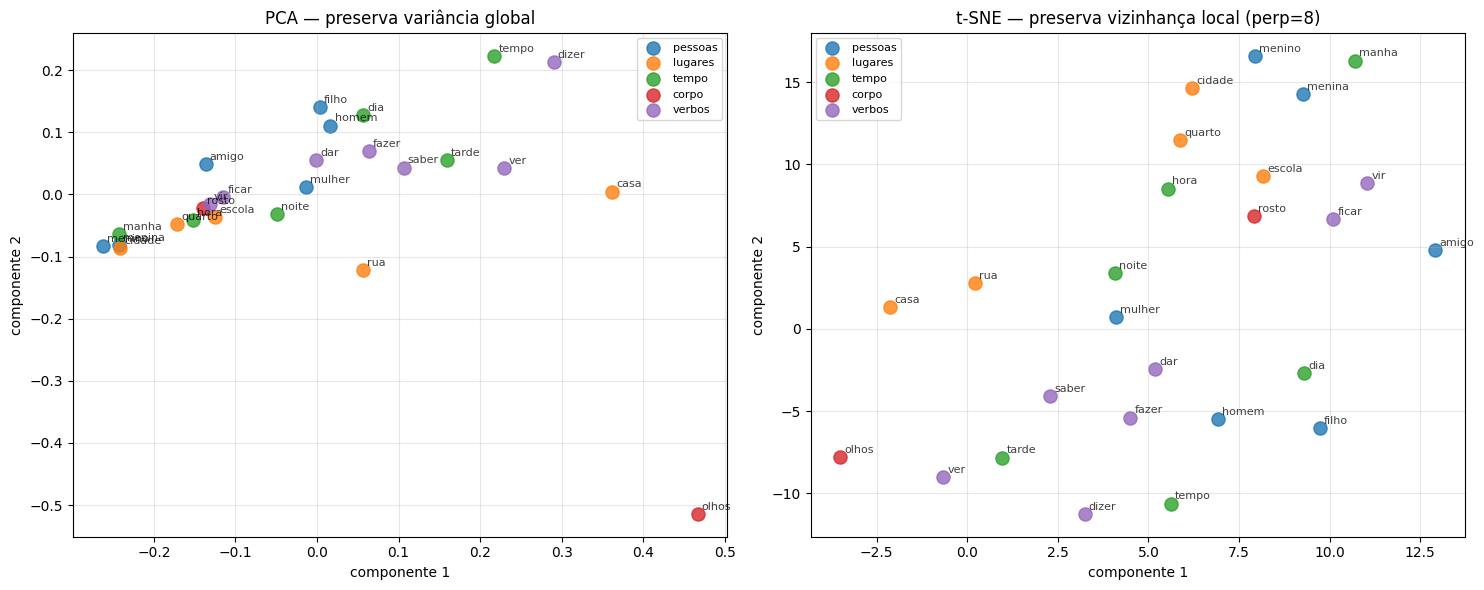

In [28]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# TODO 5: ajuste os grupos para palavras que existam no SEU vocabulário.
GRUPOS = {
    "pessoas": ["homem", "mulher", "menino", "menina", "filho", "amigo"],
    "lugares": ["casa", "cidade", "rua", "escola", "quarto"],
    "tempo": ["dia", "noite", "hora", "tempo", "manha", "tarde"],
    "corpo": ["olhos", "rosto"],
    "verbos": ["dizer", "fazer", "ver", "saber", "ficar", "vir", "dar"],
}

palavras, rotulos = [], []
for grupo, lista in GRUPOS.items():
    for p in lista:
        if p in wv:
            palavras.append(p)
            rotulos.append(grupo)

faltando = sum(len(v) for v in GRUPOS.values()) - len(palavras)
print(f"{len(palavras)} palavras encontradas ({faltando} fora do vocabulário)")
assert len(palavras) >= 10, "poucas palavras — ajuste os GRUPOS para o seu corpus"

X = np.array([wv[p] for p in palavras])
cores = {g: c for g, c in zip(GRUPOS, plt.cm.tab10.colors)}

# perplexity precisa ser menor que o número de amostras
perp = max(5, min(30, len(palavras) // 3))
print(f"t-SNE com perplexity={perp}")

proj_pca = PCA(n_components=2, random_state=42).fit_transform(X)
proj_tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init="pca").fit_transform(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for ax, proj, titulo in ((ax1, proj_pca, "PCA — preserva variância global"),
                         (ax2, proj_tsne, f"t-SNE — preserva vizinhança local (perp={perp})")):
    for grupo in GRUPOS:
        idx = [i for i, r in enumerate(rotulos) if r == grupo]
        if idx:
            ax.scatter(proj[idx, 0], proj[idx, 1], label=grupo,
                       color=cores[grupo], s=90, alpha=0.8)
    for i, p in enumerate(palavras):
        ax.annotate(p, (proj[i, 0], proj[i, 1]), fontsize=8, alpha=0.75,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_title(titulo)
    ax.set_xlabel("componente 1"); ax.set_ylabel("componente 2")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

#### A célula abaixo — a tabela de analogias (entregável do Checkpoint 4)

Testa cada analogia da lista, pulando com aviso as que tenham alguma palavra fora do vocabulário, e reporta o candidato do topo, se o esperado apareceu no top-3, e a categoria da relação.

**Como ler a saída:** a coluna `top-3?` tem três valores — `SIM` (acertou em primeiro), `top3` (apareceu, mas não no topo) e `não`. A coluna `categoria` é a que faz a análise render: compare o desempenho das analogias de gênero com o das de país→capital.

**TODO 6:** registre o resultado **real** de 4 a 6 analogias, inclusive as que falharem. As falhas são o dado que a questão-guia 3 pede — refazer o treino até dar certo e entregar só o caso bonito é o oposto do que se avalia.


In [27]:
# Analogias: rei - homem + mulher ≈ rainha
# TODO 6: teste 4 a 6 analogias e registre o resultado REAL de cada uma,
# inclusive as que falharem. As falhas são o dado mais interessante aqui.
#
# A coluna "categoria" vem da demo da Aula 3: gênero costuma funcionar,
# país→capital é notoriamente fraca. Não se promete resultado antes de rodar.

ANALOGIAS = [
    (("menino", "mulher"), ("homem",), "menina", "gênero/idade"),
    (("homem", "menina"), ("menino",), "mulher", "gênero/idade — inversa"),
    (("filho", "mulher"), ("homem",), "filha", "gênero/parentesco"),
    (("casa", "cidade"), ("rua",), "?", "livre — sem resposta esperada"),
]

TOPN_ANALOGIA = 3

print(f"{'analogia':<34} {'esperado':<10} {'obtido':<14} {'top-3?':<7} categoria")
print("-" * 100)
acertos = testadas = 0
for positivos, negativos, esperado, categoria in ANALOGIAS:
    expr = f"{positivos[0]} - {negativos[0]} + {positivos[1]}"
    faltantes = [w for w in list(positivos) + list(negativos) if w not in wv]
    if faltantes:
        print(f"{expr:<34} {esperado:<10} "
              f"{'(fora do vocab: ' + ','.join(faltantes) + ')':<22} {categoria}")
        continue

    testadas += 1
    res = wv.most_similar(positive=list(positivos), negative=list(negativos),
                          topn=TOPN_ANALOGIA)
    candidatos = [r[0] for r in res]
    top = candidatos[0]
    ok = "SIM" if top == esperado else ("top3" if esperado in candidatos else "não")
    acertos += ok == "SIM"
    print(f"{expr:<34} {esperado:<10} {top:<14} {ok:<7} {categoria}")
    print(f"{'':<34} {'':<10} top-3: {candidatos}")

if testadas:
    print(f"\n{acertos}/{testadas} analogias com acerto no top-1.")
print("\nSe a maioria falhou, isso é ESPERADO neste tamanho de corpus — e é a questão-guia 3.")
print("A analogia que falha é o resultado, não o defeito.")


analogia                           esperado   obtido         top-3?  categoria
----------------------------------------------------------------------------------------------------
menino - homem + mulher            menina     adolescencia   não     gênero/idade
                                              top-3: ['adolescencia', 'existencia', 'oleos']
homem - menino + menina            mulher     fazer          não     gênero/idade — inversa
                                              top-3: ['fazer', 'sempre', 'seria']
filho - homem + mulher             filha      filha          SIM     gênero/parentesco
                                              top-3: ['filha', 'alma', 'manhã']
casa - rua + cidade                ?          fim            não     livre — sem resposta esperada
                                              top-3: ['fim', 'filha', 'pessoa']

1/4 analogias com acerto no top-1.

Se a maioria falhou, isso é ESPERADO neste tamanho de corpus — e é a questão-guia 3.
A a

---

## O limite que este lab não consegue ultrapassar

*Medição 4 da demo da Aula 3, agora no corpus em português que você treinou.*

Você treinou **um** vetor por palavra. `banco` recebe um único vetor, que precisa servir para a instituição financeira e para o assento da praça. O resultado é um compromisso: o vetor é puxado pelos contextos financeiros para um lado e pelos contextos de praça para outro, e para numa região do espaço que não descreve bem nenhum dos dois sentidos. O mesmo vale para `manga`, `ponto`, `letra`.

Não há conserto dentro deste paradigma, porque a operação é uma **consulta a uma tabela por ID**: o vetor é buscado sem que ninguém olhe a frase em que a palavra está.

> **Erro conceitual comum:** propor "treinar mais" ou "aumentar `DIM`" como solução. Nenhuma quantidade de dados resolve, porque a limitação é da **interface** — um ID entra, um vetor sai, e a frase não participa da consulta.

A saída é fazer a representação **depender do contexto**, e o mecanismo que faz isso é a atenção: Aulas 5, 6 e 7.


#### A célula abaixo — os vizinhos de uma palavra ambígua

Procura no seu vocabulário a primeira palavra de uma lista de candidatas com dois sentidos e lista os dez vizinhos mais próximos dela.

**Como ler a saída:** classifique cada vizinho no sentido a que ele pertence e conte. Se os dois campos semânticos aparecerem **misturados na mesma lista**, você acabou de medir o limite do vetor estático — um vetor só, tentando servir a dois sentidos.

**Se nenhuma candidata existir no seu corpus:** a célula imprime as primeiras 40 palavras do vocabulário para você escolher uma à mão.


In [15]:
# Um vetor, dois sentidos — a medição que abre a Aula 5.
CANDIDATAS_AMBIGUAS = ["banco", "manga", "ponto", "letra", "estado",
                       "vela", "planta", "canal", "gosto", "capital"]

ambigua = next((p for p in CANDIDATAS_AMBIGUAS if p in wv), None)

if ambigua is None:
    print("Nenhuma das candidatas está no vocabulário deste corpus.")
    print("Escolha à mão uma palavra do seu vocabulário que tenha dois sentidos:")
    print(" ", wv.index_to_key[:40])
else:
    print(f"Vizinhos de '{ambigua}' — os 10 mais próximos:\n")
    for posicao, (vizinho, escore) in enumerate(wv.most_similar(ambigua, topn=10), start=1):
        print(f"  {posicao:>2}. {vizinho:<20} {escore:.3f}")

    print("\n" + "-" * 56)
    print("CONTAGEM (opcional, fora da rubrica) — classifique cada vizinho:")
    print("   sentido 1 (____________________):  ___ de 10")
    print("   sentido 2 (____________________):  ___ de 10")
    print("   nenhum dos dois / ruído do corpus:  ___ de 10")
    print("\nOs dois sentidos aparecem na MESMA lista, porque é o mesmo vetor.")


Vizinhos de 'ponto' — os 10 mais próximos:

   1. possivel             0.998
   2. parece               0.998
   3. posso                0.997
   4. quer                 0.997
   5. desejo               0.997
   6. mamãe                0.997
   7. acabar               0.997
   8. bom                  0.997
   9. faz                  0.997
  10. feio                 0.997

--------------------------------------------------------
CONTAGEM (opcional, fora da rubrica) — classifique cada vizinho:
   sentido 1 (____________________):  ___ de 10
   sentido 2 (____________________):  ___ de 10
   nenhum dos dois / ruído do corpus:  ___ de 10

Os dois sentidos aparecem na MESMA lista, porque é o mesmo vetor.


---

# Apêndices — opcionais, fora da rubrica

As duas células abaixo vêm dos apêndices da demo da Aula 3 e medem, **no seu corpus**, duas ressalvas que a saída dos checkpoints não mostra. Elas não valem nota; elas dão munição para as questões-guia 3 e 6.


## Apêndice 1 — O protocolo de exclusão da analogia

A avaliação padrão de analogia **exclui os três vetores de entrada** da lista de candidatos, e o `most_similar` faz isso silenciosamente. A célula abaixo roda a **mesma** conta duas vezes — a mesma aritmética vetorial, a mesma lista de candidatos — mudando só se as entradas são removidas do ranking.

Se, sem a exclusão, o topo passa a ser uma das próprias entradas, então o que o protocolo mede não é "o modelo achou a resposta": é **"o modelo achou a resposta entre as que sobraram"**.


#### A célula abaixo — a mesma analogia, com e sem a exclusão

A função `ranking_analogia` reimplementa o `most_similar` justamente para poder **desligar** a exclusão das palavras de entrada. A célula escolhe a primeira analogia cujas entradas existam no seu vocabulário e roda as duas versões sobre o mesmo vetor-alvo.

**Como ler a saída:** compare os dois rankings linha a linha. Se, sem a exclusão, o topo passa a ser uma das próprias entradas — marcadas com `<- era uma das entradas` —, então o protocolo padrão não está medindo "o modelo achou a resposta", e sim "achou a resposta **entre as que sobraram**".


In [16]:
# Apêndice 1 — a mesma analogia, com e sem a exclusão das entradas.
# A função reimplementa o most_similar justamente para poder DESLIGAR a exclusão.

def ranking_analogia(vetores, positivos, negativos, topn=5, excluir_entradas=True):
    alvo = np.zeros(vetores.vector_size, dtype=np.float64)
    for p in positivos:
        alvo += vetores.get_vector(p, norm=True)
    for n in negativos:
        alvo -= vetores.get_vector(n, norm=True)
    norma = np.linalg.norm(alvo)
    if norma < 1e-9:
        return []
    alvo = alvo / norma

    entradas = set(positivos) | set(negativos)
    escores = [(palavra, float(vetores.get_vector(palavra, norm=True) @ alvo))
               for palavra in vetores.index_to_key
               if not (excluir_entradas and palavra in entradas)]
    escores.sort(key=lambda par: -par[1])
    return escores[:topn]


# A analogia canônica vem primeiro; se ela não existir no seu corpus, a célula
# cai para a primeira da lista do Checkpoint 4 cujas entradas sobreviveram.
CANDIDATAS = [(["rei", "mulher"], ["homem"], "rainha")]
CANDIDATAS += [(list(pos), list(neg), esp) for pos, neg, esp, _ in ANALOGIAS]

escolhida = next((c for c in CANDIDATAS if all(w in wv for w in c[0] + c[1])), None)

if escolhida is None:
    print("Nenhuma das analogias conhecidas existe neste vocabulário.")
    print("Escolha três palavras do seu corpus e edite CANDIDATAS:")
    print(" ", wv.index_to_key[:40])
else:
    POSITIVOS, NEGATIVOS, ESPERADA = escolhida
    entradas = set(POSITIVOS) | set(NEGATIVOS)
    print(f"{' + '.join(POSITIVOS)} − {' − '.join(NEGATIVOS)}   (esperado: '{ESPERADA}')")
    print()

    print("COM exclusão das entradas — o protocolo padrão, o que most_similar faz:")
    for palavra, escore in ranking_analogia(wv, POSITIVOS, NEGATIVOS):
        marca = "   <- esperado" if palavra == ESPERADA else ""
        print(f"    {palavra:<20} {escore:.3f}{marca}")

    print()
    print("SEM exclusão — mesmo vetor-alvo, nada removido do ranking:")
    for palavra, escore in ranking_analogia(wv, POSITIVOS, NEGATIVOS,
                                            excluir_entradas=False):
        marca = "   <- era uma das entradas" if palavra in entradas else ""
        print(f"    {palavra:<20} {escore:.3f}{marca}")


menino + mulher − homem   (esperado: 'menina')

COM exclusão das entradas — o protocolo padrão, o que most_similar faz:
    adolescencia         0.993
    existencia           0.993
    oleos                0.993
    actos                0.993
    entrei               0.993

SEM exclusão — mesmo vetor-alvo, nada removido do ranking:
    adolescencia         0.993
    existencia           0.993
    oleos                0.993
    actos                0.993
    entrei               0.993


## Apêndice 2 — A armadilha dos antônimos

A intuição diz que `quente` e `frio` são opostos, logo distantes. A hipótese distribucional prevê o contrário: se os dois ocorrem nos **mesmos contextos**, os vetores ficam próximos — porque o que o cosseno mede aqui é **substituibilidade**, não sinonímia.

A célula ordena os pares pelo cosseno **medido no seu corpus** e mostra, ao lado, quantas vezes cada palavra ocorreu. Nada é prometido antes de rodar; as duas saídas possíveis são informação:

- `quente`/`frio` **em cima** — a previsão se confirmou, e é exatamente por isso que "vetores próximos" não pode ser lido como "significam a mesma coisa";
- `quente`/`frio` **embaixo** — olhe a coluna de ocorrências e os contextos. Com poucas ocorrências, ou em contextos que não se sobrepõem, o efeito não tem de onde sair. Isso é a questão-guia 3 de novo, e vale escrever na resposta.

Pares fora do vocabulário do seu corpus são listados à parte: isso é informação sobre o corpus, não falha da célula.


#### A célula abaixo — os pares ordenados por cosseno

Mede o cosseno de cinco pares de palavras no seu espaço, ordena do mais alto para o mais baixo e mostra ao lado quantas vezes cada palavra ocorreu no corpus.

**Como ler a saída:** veja onde `quente`/`frio` caiu — e depois olhe a coluna de **ocorrências** antes de concluir qualquer coisa. Os pares que não passaram do `min_count` são listados à parte com a contagem, e é isso que diz se o seu corpus tinha material para o efeito aparecer.


In [17]:
# Apêndice 2 — ordene os pares pelo cosseno medido no SEU corpus.
from collections import Counter

freq_corpus = Counter(p for s in sentencas for p in s)

PARES_ORDENACAO = [
    ("medico", "hospital", "médico / hospital"),
    ("gato", "parafuso", "gato / parafuso"),
    ("quente", "frio", "quente / frio   <- a armadilha"),
    ("homem", "mulher", "homem / mulher"),
    ("comer", "beber", "comer / beber"),
]

medidos = [(cosseno(wv[a], wv[b]), f"{a} / {b}", freq_corpus[a], freq_corpus[b], rotulo)
           for a, b, rotulo in PARES_ORDENACAO if a in wv and b in wv]
ausentes = [(rotulo, a, b) for a, b, rotulo in PARES_ORDENACAO
            if a not in wv or b not in wv]

if medidos:
    print(f"{'#':<3} {'cosseno':>8}  {'par':<22} {'ocorrências':>13}   nota")
    print("-" * 84)
    for posicao, (escore, par, na, nb_, rotulo) in enumerate(sorted(medidos, reverse=True), 1):
        print(f"{posicao:<3} {escore:>8.3f}  {par:<22} {f'{na} / {nb_}':>13}   {rotulo}")
else:
    print("Nenhum dos pares existe neste vocabulário — troque por palavras do seu corpus.")

if ausentes:
    print("\nFora do vocabulário deste corpus (abaixo de min_count, ou inexistentes):")
    for rotulo, a, b in ausentes:
        print(f"   - {rotulo:<24} ocorrências: {a}={freq_corpus[a]}, {b}={freq_corpus[b]}")

print("\nO cosseno alto entre antônimos, quando aparece, é consequência direta da")
print("hipótese distribucional — não é defeito da implementação. Se não apareceu,")
print("a coluna de ocorrências diz se o seu corpus tinha material para produzi-lo.")


#    cosseno  par                      ocorrências   nota
------------------------------------------------------------------------------------
1      0.991  homem / mulher               63 / 31   homem / mulher

Fora do vocabulário deste corpus (abaixo de min_count, ou inexistentes):
   - médico / hospital        ocorrências: medico=8, hospital=0
   - gato / parafuso          ocorrências: gato=9, parafuso=0
   - quente / frio   <- a armadilha ocorrências: quente=3, frio=5
   - comer / beber            ocorrências: comer=5, beber=3

O cosseno alto entre antônimos, quando aparece, é consequência direta da
hipótese distribucional — não é defeito da implementação. Se não apareceu,
a coluna de ocorrências diz se o seu corpus tinha material para produzi-lo.


---

## Extensões (opcionais, para quem terminou antes)

**(a) Treinar um BPE próprio em português** com a biblioteca `tokenizers` (`ByteLevelBPETokenizer`, vocabulário 8k) sobre o mesmo corpus, e comparar a fertilidade com a do GPT-2 no mesmo texto. Isso fecha o argumento da Aula 2 com dado do próprio aluno.

**(b) Treinar CBOW** (`sg=0`) no mesmo corpus e comparar os vizinhos com os do skip-gram. *(Requer `gensim`; se você rodou o caminho contagem + SVD, troque esta extensão por: variar `JANELA` entre 2 e 10 e comparar os vizinhos.)*

**(c) Comparar com vetores pré-treinados** de português, se houver rede e tempo. *(Requer `gensim`: `gensim.downloader` baixa da ordem de 100 MB. Lembre que cosseno **não** se compara entre espaços diferentes — a comparação honesta é entre as listas de vizinhos, não entre os números.)*

---

## Questões-guia

Respostas curtas e precisas — avaliadas por precisão conceitual, não por extensão.

**1.** Onde o WordPiece do BERT-PT ganha do BPE do GPT-2, e por quê?

> O BERT-PT tende a fragmentar menos palavras em português, porque foi treinado especificamente nesse idioma. Por exemplo, “inconstitucionalmente” foi dividida em 3 tokens pelo BERT-PT e em 7 pelo GPT-2.

**2.** O que a razão PT/EN que você mediu significa em custo e em janela de contexto — e o que ela **não** permite concluir?

> Uma razão PT/EN maior que 1 significa mais tokens em português e, em um sistema cobrado por token, maior custo e menos texto disponível na janela de contexto. No GPT-2 e BERT-EN, o português usou cerca de 111% mais tokens. Isso não permite generalizar que português sempre custa mais, pois o corpus é pequeno, possui registro específico e foram comparados poucos tokenizadores.

**3.** Por que a maioria das analogias falha no modelo treinado nesta aula? Diga qual caminho rodou no seu ambiente (skip-gram ou contagem + SVD) e cite pelo menos duas diferenças entre este setup e o do artigo do Word2Vec.

> No meu ambiente rodou Word2Vec skip-gram. A maioria das analogias falhou porque o corpus é pequeno e de domínio estreito, além do min_count=5 eliminar palavras raras. Em relação ao setup original do Word2Vec, este experimento usa um corpus e vocabulário muito menores, além de apenas 5 épocas de treinamento.

**4.** Por que o número de tokens do trecho de código muda tanto entre tokenizadores?

> Cada tokenizador possui um vocabulário diferente. Então indentação, símbolos e nomes presentes no código podem ser fragmentados de formas diferentes. Tokenizadores que tiveram mais código durante o treinamento tendem a reconhecer melhor esses padrões.

**5.** O que acontece com `min_count` maior, e por que isso é um trade-off e não um ajuste?

> Aumentar o min_count remove mais palavras raras e reduz o vocabulário, podendo gerar vetores mais estáveis para as palavras restantes. Porém, também elimina termos que podem ser semanticamente importantes, por isso existe um trade-off entre estabilidade e cobertura.

**6.** Trocar de tokenizador ou treinar embeddings próprios: qual teria mais impacto num sistema em português, e com que evidência **deste notebook**?

> Neste experimento, trocar para um tokenizador adequado ao português apresentou o impacto mais claro. O BERT-PT teve custo hipotético de 0,1135 em português contra 0,2110 do GPT-2 e permitiu 721 pares na janela contra 388, enquanto os embeddings próprios, treinados no corpus pequeno, acertaram apenas 1 de 4 analogias.

---

## Declaração de uso de IA

*Quais ferramentas de IA você usou neste lab e para quê. Duas linhas.*

> Usei o GPT-5.6 Sol como apoio durante a atividade, principalmente para interpretar o que precisava ser feito.
Também me orientou nas alterações do notebook, na interpretação dos resultados obtidos e na formulação/revisão das respostas.